# Which fifty members spent the most in Q2?

**Week 2, Wednesday. Chapter 1 of 6.** The day climbs one case, Marketing's protect list,
and this is its first chapter.

> "Retail-Plus frequency is the problem, so we want to protect our best members before they
> drift. Give us the top fifty customers by Q2 revenue in each segment, and flag anyone whose
> monthly spend has fallen for two months running."
> The marketing lead, Kalpa Retail

**Who needs the answer.** The marketing lead owns acquisition and campaigns at Kalpa Retail,
and this quarter's protect budget, a call from the member team and a renewal offer, goes to
the members this list names. A list built on the wrong unit sends the offer to the wrong
people: every best member it misses is one nobody called, and every member it repeats is a
call made twice.

**The questions on the way.**
1. Which ways could the team build a ranked list, and what would each cost?
2. What did each member book in Q2?
3. Which fifty members spent the most?
4. What does the quickest list, the fifty biggest orders, give Marketing?
5. Which segments does the list of fifty members reach?
6. Does a sort in Python pick the same fifty members?

**The metric at stake.** Q2 revenue per member: the booked amount of every Q2 order the
member placed, whatever its status, which is how Monday's suite reached Rs 9,84,00,000 for
the quarter. Q2 is July to September 2026. A member is one customer on the customers table.
Kalpa Retail sells to four segments: Business (corporate buyers, whose orders run to
lakhs), Retail-Core (everyday shoppers), Retail-Plus (the paid membership tier) and Student.
The retail dossier, `content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, says in section 2 what a paid tier like Retail-Plus buys a
retailer and what its head watches, and in section 4 what Marketing and the head of
Retail-Plus ask the data team.

**Where the week left off.** Monday put Week 1's revenue tree on the warehouse, Kalpa's
Postgres database: Q2 booked Rs 9,84,00,000 on 462 orders from 227 members who bought, and
Retail-Plus carried the fall, with fewer of its members buying and each ordering less often.
Tuesday attached payments to orders and kept one rule: a join is only done when its row
count is explained. Today ranks members on Monday's booked revenue.

**A real company with the same question.** Starbucks Rewards members made 59 percent of the
money tendered at Starbucks' company-operated US stores in the quarter that ended on 28 June
2026, and 35.8 million US members were active in the 90 days to that date (Starbucks' card,
loyalty and mobile dashboard for the third quarter of fiscal 2026, checked 1 October 2026).
When members carry more than half of the money, a list of which members carry it is the
first thing a retention offer needs.

**Setup.** The next cell finds the shared helper, `c2kit`, by walking up from this folder
until it reaches `scripts/`, connects to the Kalpa warehouse and reads the named queries in
`../sql/C2_W02_D03_01_top_fifty_STUDENT.sql`. Every query below is a block of that file, so what
runs here is exactly what runs from VS Code. If no database answers, the error names the
command that loads the warehouse: `bash .devcontainer/load_warehouse.sh`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
from decimal import Decimal
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D03_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def num(v):
    """A database number as a Python int or float."""
    if isinstance(v, Decimal):
        return int(v) if v == v.to_integral_value() else float(v)
    return v

def rows(query):
    """Run a query and hand back its rows with every number as a Python number."""
    return [{k: num(v) for k, v in r.items()} for r in kit.sql(query)]

def show(found, caption="", money=(), limit=12):
    """Rows as the kit's table, with the columns named in money set in rupees."""
    if not found:
        kit.table(["result"], [["no rows"]], caption)
        return
    heads = list(found[0])
    def cell(h, v):
        v = num(v)
        if v is None:
            return "NULL"
        if h in money:
            return kit.rupees(v)
        return f"{v:,}" if isinstance(v, int) and abs(v) >= 10000 else str(v)
    body = [[cell(h, r[h]) for h in heads] for r in found[:limit]]
    if len(found) > limit:
        body.append(["..." for _ in heads])
    kit.table(heads, body, caption)

def run(name, caption="", money=(), limit=12, echo=True):
    """Print a named block, run it, show its rows and hand them back."""
    if echo:
        print(Q[name])
    found = rows(Q[name])
    show(found, caption, money, limit)
    return found

def lakh(v):
    """Rupees in lakh, for an axis that has to hold Business and retail members at once."""
    return f"{v / 100000:,.1f} lakh"

Q = blocks("01_top_fifty")
print(len(Q), "named queries read from", "C2_W02_D03_01_top_fifty_STUDENT.sql;",
      kit.sql("select version()")[0]["version"].split(",")[0])

11 named queries read from C2_W02_D03_01_top_fifty_STUDENT.sql; PostgreSQL 16.14 (Ubuntu 16.14-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu


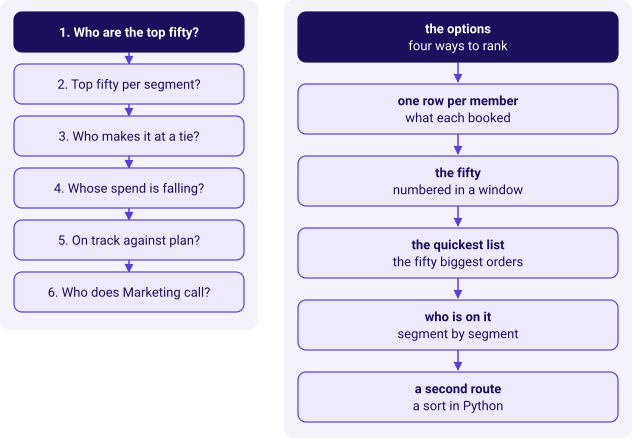

In [2]:
kit.side_by_side(
    kit.ladder(['Who are the top fifty?', 'Top fifty per segment?', 'Who makes it at a tie?', 'Whose spend is falling?', 'On track against plan?', 'Who does Marketing call?'], lit=0, show=False),
    kit.vflow(['the options\nfour ways to rank', 'one row per member\nwhat each booked', 'the fifty\nnumbered in a window', 'the quickest list\nthe fifty biggest orders', 'who is on it\nsegment by segment', 'a second route\na sort in Python'], lit=0, show=False),
)

## The options: which ways could the team build a ranked list, and what would each cost?

A team could hand Marketing a ranked list in four ways. They differ in what one row of the
answer is, and in what the four segment lists Marketing asked for would take: how many
queries, and how many rows leave the warehouse.

| Option | What one row of the answer is | Its place on the list | For the four segment lists |
|---|---|---|---|
| A. Sort the Q2 order rows and keep fifty | an order | the row's position on screen | four sorts of order rows, so each list holds orders |
| B. Group by member, sort, keep fifty with LIMIT | a member | the row's position on screen | one sorted query per segment, four glued together |
| C. Group by member, number the members in a window, keep places 1 to 50 | a member, with its place | a column a later step can count or filter | one query, with one more phrase |
| D. Export the orders to a spreadsheet and sort by hand | whatever the sort gives | typed by hand | every Q2 order row out, and four sorts by hand |

A window function computes a value for each row from related rows and keeps every row,
where GROUP BY collapses each group to one. `row_number() OVER (ORDER BY q2_revenue DESC)`
numbers the members from the biggest down.

**Predict before you run.** For the per-segment list Marketing asked for, how many queries
does option B need, against option C?

- a) One each, since both group by member.
- b) Four for B, one per segment, against one for C.
- c) Fifty for B, one per place, against one for C.
- d) None for either, since LIMIT 50 already works per segment.

option,rows that leave the warehouse,one row is,for the four segment lists
A. sort the orders,188,order,4 queries
"B. group, sort, LIMIT",155,member,4 queries
"C. group, number in a window",155,member and place,1 query
D. export and sort by hand,462,"order, by hand",4 sorts by hand


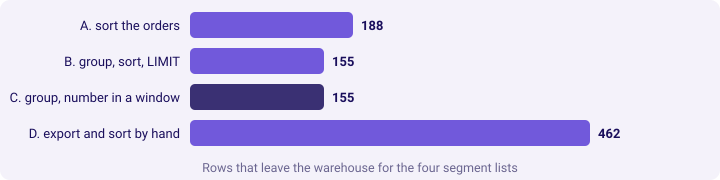

In [3]:
q2_orders = rows(Q["c1_q2_book"])[0]["orders"]
segments = rows(Q["c1_segments"])
per_segment_rows = sum(min(50, s["members_who_bought"]) for s in segments)
per_segment_orders = sum(min(50, s["orders"]) for s in segments)
sizing = [("A. sort the orders", per_segment_orders, "order", f"{len(segments)} queries"),
          ("B. group, sort, LIMIT", per_segment_rows, "member", f"{len(segments)} queries"),
          ("C. group, number in a window", per_segment_rows, "member and place", "1 query"),
          ("D. export and sort by hand", q2_orders, "order, by hand", f"{len(segments)} sorts by hand")]
kit.table(["option", "rows that leave the warehouse", "one row is", "for the four segment lists"],
          [(o, n, unit, extra) for o, n, unit, extra in sizing],
          caption=f"Sized on this warehouse for the four segment lists: {q2_orders} Q2 orders, "
                  f"{len(segments)} segments, at most fifty rows from each")
kit.bars([(o, n) for o, n, _, _ in sizing],
         title="Rows that leave the warehouse for the four segment lists",
         lit=(2,))

**What happened.** The answer is b. LIMIT counts rows across the whole result, so option B
needs one sorted query per segment, four in all, glued together, to move the same 155 rows
that option C moves in one query; option C numbers the members once and restarts the
numbering per segment with one more phrase, which chapter 2 writes. Option A moves 188 rows
that are orders, fifty from each segment's orders and Student's 38, so each list still names
orders. Option D moves all 462 Q2 order rows out of the warehouse, which the data platform
lead's rule, "query it, do not export it", rules out.

**The best-fit call.** Option C, because Marketing's ask is per segment and the place has to
be a column that a later step can count and filter, which option B's screen position is
not. What would change the call is Marketing wanting one overall list to read by eye and
nothing more: then option B is shorter and returns the same fifty members, and the place as
a column would earn nothing.

In [4]:
kit.check("Q2 holds 462 orders", q2_orders == 462, f"{q2_orders} orders")
kit.check("four segments bought in Q2", len(segments) == 4, ", ".join(s["segment"] for s in segments))
kit.check("the export moves more rows than either query", sizing[3][1] > sizing[2][1], f"{sizing[3][1]} against {sizing[2][1]}")
kit.check("the four segment lists hold 155 members", per_segment_rows == 155, f"{per_segment_rows} rows")

**The day's picture.** GROUP BY keeps one row per group, so it answers how much each group
booked and keeps nothing below the group. A window keeps every row and adds one column beside
it, and each of Marketing's three asks needs that column: a member's place, a member's last
month, and the quarter's total so far.

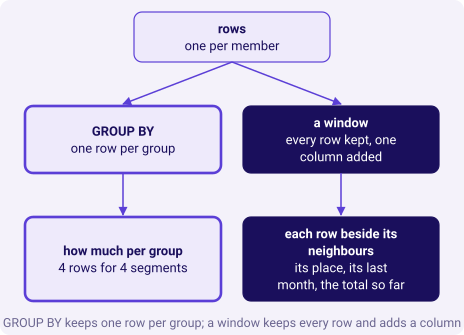

In [5]:
kit.tree({"label": "rows\none per member", "branches": [
    ("", {"label": "GROUP BY\none row per group", "kind": "known", "branches": [
        ("", {"label": "how much per group\n4 rows for 4 segments", "kind": "known"})]}),
    ("", {"label": "a window\nevery row kept, one column added", "kind": "lit", "branches": [
        ("", {"label": "each row beside its neighbours\nits place, its last month, the total so far",
              "kind": "lit"})]})]},
    title="GROUP BY keeps one row per group; a window keeps every row and adds a column")

## 1. What did each member book in Q2?

A ranked list of members needs one row per member first. The orders table holds one row per
order, so the member's Q2 revenue is the sum of their Q2 orders, grouped by member.

**Predict before you run.** How many rows does one row per member give for Q2?

- a) 462, one per Q2 order.
- b) 340, one per member on the customers table.
- c) 227, one per member who placed a Q2 order.
- d) 50, the length of Marketing's list.

227 member rows, 462 orders, Rs 9,84,00,000
-- The question: how many members bought in Q2 in each segment, and what did each segment book?
SELECT c.segment,
       count(DISTINCT o.customer_id) AS members_who_bought,
       count(*)                      AS orders,
       sum(o.amount)                 AS q2_revenue
FROM   orders o
JOIN   customers c USING (customer_id)
WHERE  o.quarter = 'Q2'
GROUP  BY c.segment
ORDER  BY q2_revenue DESC;


segment,members_who_bought,orders,q2_revenue
Business,35,91,"Rs 9,75,84,600"
Retail-Plus,76,140,"Rs 4,13,380"
Retail-Core,96,193,"Rs 3,66,250"
Student,20,38,"Rs 35,770"


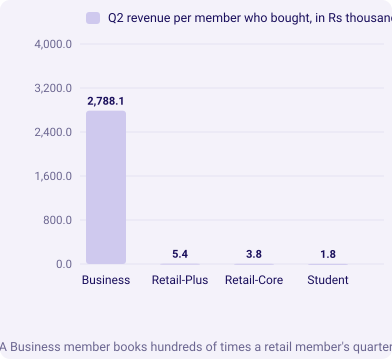

In [6]:
members = rows(Q["c1_member_spend"])
print(f"{len(members)} member rows, {sum(m['q2_orders'] for m in members)} orders, "
      f"{kit.rupees(sum(m['q2_revenue'] for m in members))}")
run("c1_segments", "Q2 by segment: members who bought, their orders and what they booked",
    money=("q2_revenue",))
kit.columns([s["segment"] for s in segments],
            [("Q2 revenue per member who bought, in Rs thousand",
              [s["q2_revenue"] / s["members_who_bought"] / 1000 for s in segments])],
            title="A Business member books hundreds of times a retail member's quarter",
            fmt=lambda v: f"{v:,.1f}")

**What happened.** The answer is c: 227 rows, one per member who placed a Q2 order. The
customers table holds 340 members, and 113 of them bought nothing in Q2, so they have no Q2
revenue to rank. The 227 rows carry all 462 orders and all Rs 9,84,00,000. A Business
member booked about Rs 27.9 lakh in the quarter on average, against about Rs 3,800 for a
Retail-Core member and Rs 5,400 for a Retail-Plus member, and that gap shapes every list
that ranks the whole book at once.

In [7]:
kit.check("one row per member who bought", len(members) == 227, f"{len(members)} rows")
kit.check("the member rows carry every Q2 order", sum(m["q2_orders"] for m in members) == 462)
kit.check("the member rows add back to Q2's Rs 9,84,00,000",
          sum(m["q2_revenue"] for m in members) == 98400000)
kit.check("no member appears twice", len({m["customer_id"] for m in members}) == len(members))

## 2. Which fifty members spent the most?

Option C in full: a named step adds up each member's Q2, a window numbers the members from
the biggest down, and the outer query keeps places 1 to 50. The customer id after the
revenue in the window's ORDER BY decides any two members who booked the same, so the
numbering is the same on every run; chapter 3 asks whether that is fair.

```sql
ranked AS (
    SELECT customer_id, segment, q2_orders, q2_revenue,
           row_number() OVER (ORDER BY q2_revenue DESC, customer_id) AS position
    FROM   q2_spend
)
SELECT ... FROM ranked WHERE position <= 50 ORDER BY position;
```

**Predict before you run.** How many of the four segments will the fifty members come
from?

- a) All four, since every segment has big spenders.
- b) Three.
- c) Two.
- d) One, Business.

-- Option C: group by member in a named step, number every member in a window, keep positions 1 to 50.
-- row_number() OVER (ORDER BY ...) keeps every member's row and adds its place in the order, and the
-- customer id breaks any tie in revenue so the numbering is the same on every run.
WITH q2_spend AS (
    SELECT o.customer_id,
           c.segment,
           count(*)      AS q2_orders,
           sum(o.amount) AS q2_revenue
    FROM   orders o
    JOIN   customers c USING (customer_id)
    WHERE  o.quarter = 'Q2'
    GROUP  BY o.customer_id, c.segment
),
ranked AS (
    SELECT customer_id, segment, q2_orders, q2_revenue,
           row_number() OVER (ORDER BY q2_revenue DESC, customer_id) AS position
    FROM   q2_spend
)
SELECT position, customer_id, segment, q2_orders, q2_revenue
FROM   ranked
WHERE  position <= 50
ORDER  BY position;
50 members on the list, places 1 to 50; segments: {'Business': 35, 'Retail-Plus': 11, 'Retail-Core': 4}


position,customer_id,segment,q2_revenue
33,C-0303,Business,"Rs 5,73,000"
34,C-0292,Business,"Rs 3,52,000"
35,C-0302,Business,"Rs 2,25,000"
36,C-0170,Retail-Plus,"Rs 21,740"
37,C-0167,Retail-Plus,"Rs 14,600"
38,C-0010,Retail-Core,"Rs 13,910"
39,C-0160,Retail-Plus,"Rs 13,700"
40,C-0040,Retail-Core,"Rs 13,550"


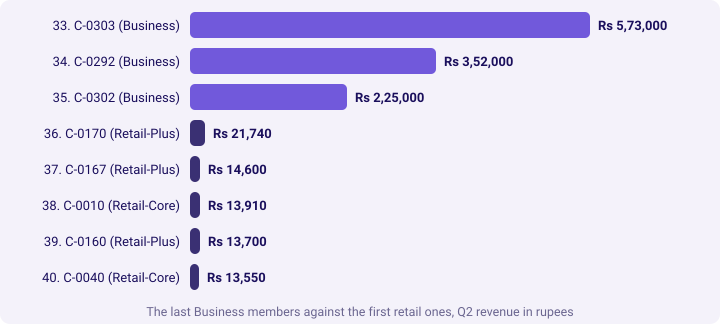

In [8]:
print(Q["c1_top_fifty"])
fifty = rows(Q["c1_top_fifty"])
fifty_b = rows(Q["c1_top_fifty_groupby"])
by_segment = {}
for r in fifty:
    by_segment[r["segment"]] = by_segment.get(r["segment"], 0) + 1
print(f"{len(fifty)} members on the list, places {fifty[0]['position']} to {fifty[-1]['position']}; "
      f"segments: {by_segment}")
edge = run("c1_where_business_ends", "Places 33 to 40: where Business ends", money=("q2_revenue",),
           echo=False)
kit.bars([(f"{r['position']}. {r['customer_id']} ({r['segment']})", r["q2_revenue"]) for r in edge],
         title="The last Business members against the first retail ones, Q2 revenue in rupees",
         fmt=kit.rupees, lit=tuple(i for i, r in enumerate(edge) if r["segment"] != "Business"))

**What happened.** The answer is b: three segments. The list holds 35 Business members,
which is every Business member who bought in Q2, then 11 Retail-Plus and 4 Retail-Core, and
no Student at all. The last Business member, at place 35, booked Rs 2,25,000; the first
retail member, at place 36, booked Rs 21,740, about a tenth of it. Ranked across the whole
book, any Business buyer outranks every retail member.

In [9]:
kit.check("the list holds fifty members", len(fifty) == 50 and len({r["customer_id"] for r in fifty}) == 50)
kit.check("option B's LIMIT returns the same fifty members",
          {r["customer_id"] for r in fifty} == {r["customer_id"] for r in fifty_b})
kit.check("the places run from 1 to 50 with no gap", [r["position"] for r in fifty] == list(range(1, 51)))
kit.check("every Business buyer is on the list", by_segment.get("Business") == 35, f"{by_segment.get('Business')} of 35")

## 3. What does the quickest list, the fifty biggest orders, give Marketing?

Under deadline, the shortest query that looks like the ask sorts the Q2 orders by amount and
keeps fifty.

```sql
SELECT o.order_id, o.customer_id, c.segment, o.amount
FROM   orders o JOIN customers c USING (customer_id)
WHERE  o.quarter = 'Q2'
ORDER  BY o.amount DESC, o.order_id
LIMIT  50;
```

**Predict before you run.** How many different members does that list of fifty rows name?

- a) 50, one per row.
- b) About 45, since a few members placed two big orders.
- c) Fewer than 30.
- d) It cannot be known without reading every row.

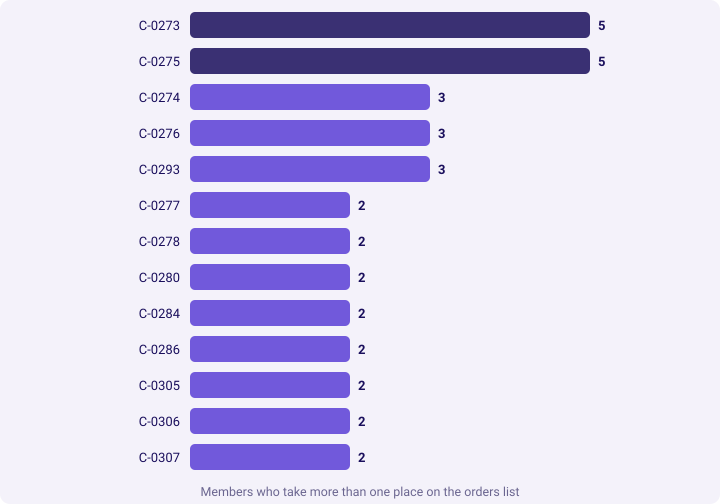

In [10]:
hurried = rows(Q["c1_top_orders_check"])[0]
kit.stats([(hurried["rows_on_the_list"], "rows on the list", "what the report would say it holds"),
           (hurried["different_members"], "different members", "what Marketing would actually call"),
           (hurried["segments"], "segment", "Business only")],
          caption="The plausible wrong answer: the fifty biggest Q2 orders, sent as the top fifty members")
repeats = rows(Q["c1_top_orders_repeats"])
kit.bars([(r["customer_id"], r["times_on_the_list"]) for r in repeats],
         title="Members who take more than one place on the orders list", lit=(0, 1))

**The plausible wrong answer.** The list has fifty rows and names only 28 members, every one
of them Business. Two companies hold five places each, eleven more hold two or three, and
no Retail-Plus, Retail-Core or Student member appears at all. The answer to the prediction
is c.

**Why it is wrong.** One row of the orders table is an order, so a member with five large
orders takes five places, and a member whose quarter is many smaller orders never shows.
Marketing would ring 28 companies, two of them five times, and not one member of the tier it
is worried about.

**The check that exposes it.** Count the different members on the list and set the count
beside its rows. A list of members holds as many members as rows; this one holds 28 for 50.

**The fix, and what it changed.** Add up each member's orders first and rank the members,
which is section 2's list: 50 rows, 50 members, three segments. The fix reaches 22 more
members, seven Business members the orders list missed and the 15 retail members it could
never show.

In [11]:
members_on_member_list = {r["customer_id"] for r in fifty}
orders_list = rows(Q["c1_top_orders_hurried"])
members_on_orders_list = {r["customer_id"] for r in orders_list}
kit.check("the orders list repeats members: fewer members than rows",
          hurried["different_members"] < hurried["rows_on_the_list"],
          f"{hurried['different_members']} members for {hurried['rows_on_the_list']} rows")
kit.check("the member list names one member per row",
          len(members_on_member_list) == len(fifty) == 50)
kit.check("every member on the orders list is also on the member list",
          members_on_orders_list <= members_on_member_list)
kit.check("the fix reaches 22 more members", len(members_on_member_list - members_on_orders_list) == 22,
          f"{len(members_on_member_list - members_on_orders_list)} more")

## 4. Which segments does the list of fifty members reach?

The member list is the right unit, and Marketing's ask also says "in each segment". Count
the list by segment, with every segment in the count, including one with nobody on the list.

**Predict before you run.** How many Student members are on the one list of fifty?

- a) None.
- b) About five, since Student is about a tenth of the members.
- c) All twenty Student members who bought.
- d) Fifty, one list per segment.

segment,on_the_list,members_who_bought
Business,35,35
Retail-Plus,11,76
Retail-Core,4,96
Student,0,20


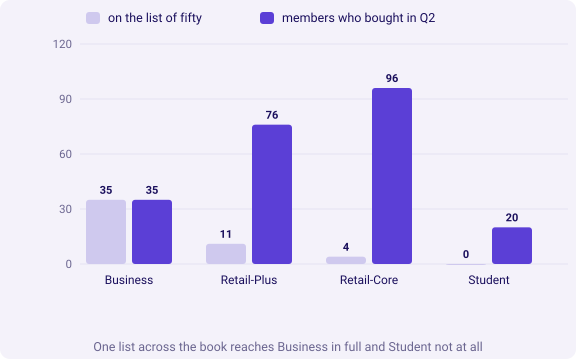

In [12]:
reach = run("c1_list_by_segment", "The one list of fifty, counted by segment", echo=False)
kit.columns([r["segment"] for r in reach],
            [("on the list of fifty", [r["on_the_list"] for r in reach]),
             ("members who bought in Q2", [r["members_who_bought"] for r in reach])],
            title="One list across the book reaches Business in full and Student not at all")

**What happened.** The answer is a: no Student member. Business has all 35 of its buyers on
the list, Retail-Plus 11 of its 76, Retail-Core 4 of its 96 and Student none of its 20. The
tier Marketing is worried about gets eleven places, because any Business buyer outranks
every retail member. Marketing asked for fifty in each segment, and that is chapter 2's
question.

In [13]:
got = {r["segment"]: r["on_the_list"] for r in reach}
kit.check("the counts add back to fifty", sum(got.values()) == 50, str(got))
kit.check("the Student line is printed with nobody on it", got.get("Student") == 0)
kit.check("Retail-Plus holds 11 places of 50", got.get("Retail-Plus") == 11)

## A second route: does a sort in Python pick the same fifty members?

The second route reaches the list without SQL's GROUP BY or its window: it pulls the 462 Q2
order rows into Python, adds up each member's rupees in a dictionary, sorts the members by
revenue and then by id, and keeps fifty. A slip in the window's ORDER BY could not move this
list, since the two share no code.

**Predict before you run.** Will Python's fifty match the window's fifty member for member?

- a) Yes, since both add up the same orders and break a tie by the same id.
- b) No, since Python sorts text and numbers differently.
- c) Only the first thirty-five, the Business members.
- d) Only if the rows arrive sorted from the database.

In [14]:
raw = rows(Q["c1_rows_for_python"])
spend, segment_of = {}, {}
for r in raw:
    spend[r["customer_id"]] = spend.get(r["customer_id"], 0) + r["amount"]
    segment_of[r["customer_id"]] = r["segment"]
py_fifty = sorted(spend, key=lambda cid: (-spend[cid], cid))[:50]
py_segments = {}
for cid in py_fifty:
    py_segments[segment_of[cid]] = py_segments.get(segment_of[cid], 0) + 1
kit.table(["route", "rows read", "members", "Business", "Retail-Plus", "Retail-Core", "Student"],
          [("SQL window", 462, len(fifty), by_segment.get("Business", 0), by_segment.get("Retail-Plus", 0),
            by_segment.get("Retail-Core", 0), by_segment.get("Student", 0)),
           ("Python sort", len(raw), len(py_fifty), py_segments.get("Business", 0),
            py_segments.get("Retail-Plus", 0), py_segments.get("Retail-Core", 0), py_segments.get("Student", 0))],
          caption="Two routes, one list")

route,rows read,members,Business,Retail-Plus,Retail-Core,Student
SQL window,462,50,35,11,4,0
Python sort,462,50,35,11,4,0


In [15]:
kit.check("Python read every Q2 order row", len(raw) == 462)
kit.check("Python's fifty are the window's fifty", py_fifty == [r["customer_id"] for r in fifty])
kit.check("Python's segment counts match", py_segments == by_segment)

**What happened.** The answer is a. Both routes add up the same 462 orders and break a tie
by the same id, so they name the same fifty members in the same order, 35 Business, 11
Retail-Plus and 4 Retail-Core. The Python route moved 462 rows out of the warehouse to reach
what the query sent back in 50, so it runs as the check and the query is what Marketing gets.

Kavya Nair is the senior analyst on Kalpa Retail's data team, who checks every number before
it leaves the team, and her review closes each chapter.

> **Kavya's review.** Say what one row of your list is before you say who is on it. A top
> fifty of orders and a top fifty of members look alike on screen and send Marketing to
> different people.

### In the interview: how is a window different from GROUP BY, and what is one row of your answer?

**[S] What is the difference between GROUP BY and a window function?** GROUP BY collapses
each group to one row and can only return what describes the group, such as its sum or its
count. A window function computes over related rows and keeps every row, so each member
keeps its own line and gains a column, here its place in the order. A top fifty needs the
rows kept and numbered, which is a window's job.

**[F] Marketing asks for the top fifty customers, and your list has fifty rows but only
twenty-eight names. What happened, and what is your check?** The list ranked order rows, so
a customer with several big orders took several places. The check is
`count(DISTINCT customer_id)` beside `count(*)` on the finished list, which must agree on a
list of customers; the fix is to add up each customer's orders in a named step and rank the
customers.

### Depth: how much of Q2 does the one list of fifty carry?

Protecting revenue alone would make the overall list look complete, since the fifty members
on it booked almost all of Q2. The share below is the reason Marketing asked per segment:
the rupees sit with Business, and the drift Marketing fears sits in Retail-Plus.

In [16]:
carried = sum(r["q2_revenue"] for r in fifty)
kit.stats([(kit.rupees(carried), "booked by the fifty", "out of Rs 9,84,00,000"),
           (f"{100 * carried / 98400000:.1f}%", "of Q2", "on 50 of 227 members who bought")],
          caption="The one list of fifty carries almost all of Q2")
kit.check("the fifty carry more than 99 percent of Q2", carried / 98400000 > 0.99, f"{100 * carried / 98400000:.2f}%")

## So which fifty members spent the most in Q2?

1. **Which way, at what cost?** Group by member and number the members in a window, option
   C: one query moves the four segment lists' 155 rows with the place as a column, where
   option B needs four glued queries for the same rows and the export moves all 462 Q2 order
   rows.
2. **What did each member book?** One row for each of the 227 members who bought, carrying
   all 462 orders and Rs 9,84,00,000.
3. **Which fifty spent the most?** 35 Business members, every Business buyer, then 11
   Retail-Plus and 4 Retail-Core.
4. **What does the quickest list give?** Fifty orders naming only 28 members, all Business;
   counting members beside rows catches it, and ranking members fixes it.
5. **Which segments does the list reach?** Three of four: Retail-Plus holds 11 places and
   Student none.
6. **Does Python agree?** Yes, member for member, after moving 462 rows to do it.

Chapter 2 asks the question Marketing put: which fifty members lead each segment?

In [17]:
kit.check_summary()